In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Load the segmented data
df = pd.read_csv('final_customer_segments.csv')

# 2. Select Recency, Frequency, and Monetary columns for clustering
X = df[['Recency', 'Frequency', 'Monetary']]

# 3. Scale the data (Machine learning algorithms require normalized data to perform well)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply K-Means clustering (let's find 4 optimal clusters for our customers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View the first 5 rows with their new Machine Learning clusters
df.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,M_Score,F_Score,RFM_Segment,Customer_Segment,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,4,1,414,Champions (VIP),0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,New / Promising,0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,1,112,Lost / Low Value,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Lost / Low Value,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,4,1,214,At Risk (High Value),1


In [4]:
# 1. Load the original raw dataset again to get purchase dates and customer IDs
raw_df = pd.read_csv('rfm_data.csv')
raw_df['order_purchase_timestamp'] = pd.to_datetime(raw_df['order_purchase_timestamp'])

# 2. Extract the year and month of the first purchase for each customer (Cohort Month)
raw_df['order_month'] = raw_df['order_purchase_timestamp'].dt.to_period('M')
raw_df['cohort'] = raw_df.groupby('customer_unique_id')['order_month'].transform('min')

# 3. Calculate the index of month difference between purchase and cohort
def get_month_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year * 12 + month

raw_df['cohort_year'] = raw_df['cohort'].dt.year
raw_df['cohort_month'] = raw_df['cohort'].dt.month
raw_df['order_year'] = raw_df['order_month'].dt.year
raw_df['order_month_num'] = raw_df['order_month'].dt.month

raw_df['cohort_index'] = (raw_df['order_year'] - raw_df['cohort_year']) * 12 + (raw_df['order_month_num'] - raw_df['cohort_month']) + 1

# 4. Create the cohort matrix (Retention Table)
cohort_data = raw_df.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_unique_id')

# 5. Calculate retention percentage
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0) * 100

# Display the retention matrix
retention_matrix.round(2)

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
cohort,,,,,,,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.55,NaN,NaN,NaN,NaN,NaN,NaN,0.55,NaN,NaN,NaN,NaN,0.55
2016-12,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,NaN,0.20,0.20,0.40,NaN,0.20,0.20,0.20,NaN,NaN,NaN,0.20,0.20,NaN,NaN,0.20,0.60,NaN
2017-02,100.0,0.18,0.18,0.09,0.53,NaN,0.26,0.09,0.09,0.18,0.18,0.26,0.09,0.18,0.18,NaN,0.09,0.09,NaN
2017-03,100.0,0.22,0.33,0.28,0.06,0.22,0.06,0.17,0.22,0.11,0.17,0.06,0.11,0.11,0.17,0.11,0.06,0.11,NaN
2017-04,100.0,0.38,0.19,0.13,0.13,0.13,0.25,0.13,0.19,0.13,0.31,0.13,0.06,NaN,0.06,NaN,0.13,NaN,NaN
2017-05,100.0,0.33,0.45,0.12,0.25,0.08,0.37,0.12,0.21,0.25,0.12,0.29,0.17,0.04,0.04,0.12,NaN,NaN,NaN
2017-06,100.0,0.37,0.18,0.18,0.23,0.23,0.14,0.23,0.09,0.18,0.23,0.18,0.23,0.05,0.09,NaN,NaN,NaN,NaN
2017-07,100.0,0.56,0.22,0.19,0.26,0.15,0.22,0.15,0.15,0.15,0.22,0.19,0.19,0.19,NaN,NaN,NaN,NaN,NaN


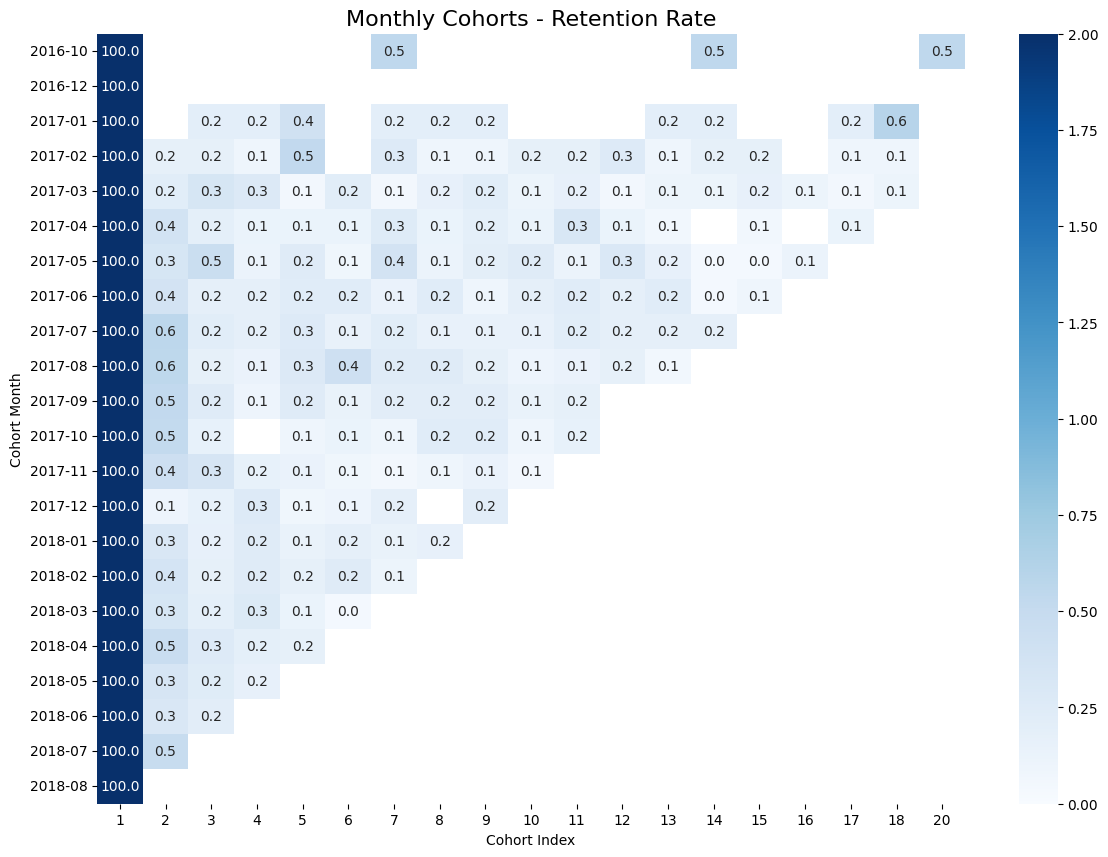

In [5]:
import seaborn as sns

plt.figure(figsize=(14, 10))
plt.title('Monthly Cohorts - Retention Rate', fontsize=16)
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=2)
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()